# Gaia y K-means: componentes espaciales y curvas de luz de lentes gravitacionales

**Adaptación y documentación:** Matías Almonacid Mellado.  
**Notebook base:** facilitado por el Dr. Timo Anguita, director del Doctorado en Astrofísica de la Universidad Andrés Bello, sede Santiago.

Se utilizan observaciones de fuentes FPR preseleccionadas alrededor de un catálogo de 340 sistemas. El análisis organiza las observaciones dentro de 3 arcsec en grupos espaciales y construye comparaciones temporales. **H1413+117** sirve como ejemplo explicado, con 143 observaciones de la fuente Gaia `1225461582386571008`. El objetivo es preparar datos trazables para una exploración posterior de microlensing. Una diferencia de magnitudes, por sí sola, requiere interpretación física.

El notebook base se conserva sin modificaciones en `reference/`. Sus salidas guardadas son independientes de la implementación actual. Las fuentes se citan en el texto y se reúnen al final.

## 1. El problema

Una lente gravitacional puede producir varias imágenes próximas de un cuásar. Su brillo puede variar por la emisión intrínseca, la magnificación y los efectos instrumentales, mientras que las trayectorias ópticas introducen retardos temporales. La interpretación de microlensing requiere tener en cuenta esos efectos [5, 6].

Aquí preguntamos cómo construir grupos espaciales reproducibles y comparaciones de magnitud con épocas e identificadores explícitos. La tabla `gaiafpr.lens_observation` pertenece al Gaia Focused Product Release [1, 2]. La etapa oficial GravLens utiliza DBSCAN [1]; el K-means de este notebook es una exploración posterior.

## 2. Entorno

Utilizamos la copia de los datos incluida en el proyecto. Los parámetros se cargan desde `config.json` y las funciones son las mismas que utiliza `run_analysis.py`.

Las rutas son relativas a la carpeta del repositorio. El notebook puede abrirse desde esa carpeta o desde `notebooks/`.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

raiz = Path.cwd()
if not (raiz / "config.json").is_file():
    raiz = raiz.parent
if not (raiz / "config.json").is_file():
    raise FileNotFoundError("Abre el notebook desde el repositorio o desde notebooks/.")
sys.path.insert(0, str(raiz))

from src.lens_analysis import (
    CLAVE_OBSERVACION, cargar_datos, asociar_catalogo, analizar_componentes,
    construir_pares, figura_sistema, figura_diferencias, exportar_resultados,
)
parametros = json.loads((raiz / "config.json").read_text())
display(pd.Series(parametros, name="Valor").to_frame())

,Valor
radio_arcsec,3.0
semilla,42
n_init,20
semillas_estabilidad,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]"
muestra_silueta,1000
tolerancia_segundos,1.0
source_ids_file,data/raw/selected_source_ids.csv


## 3. Datos y procedencia

El catálogo fue facilitado junto al notebook base; se conserva sin cambios. El CSV no permite confirmar la versión de su exportación.

Se preseleccionaron 390 fuentes mediante centros de componentes FPR a menos de 10 arcsec de las posiciones del catálogo. Se descargaron todas sus observaciones y el análisis aplica después el radio de 3 arcsec por observación. La consulta y la lista de fuentes quedan registradas en el repositorio.

Según Gaia, `component_id` identifica un componente dentro de cada `source_id`, mientras que `observation_id` es un contador por componente [2]. Por eso no mezclamos fuentes ni emparejamos observaciones por el número de ese contador.

`g_mag_obs` contiene magnitudes G estimadas a bordo. `epoch_obs` está en **BJD (TCB) − 2455197.5, en días** [2]. Los errores de flujo se conservan si existen, pero no se convierten automáticamente en errores de estas magnitudes. Los identificadores largos se leen como texto para conservar sus dígitos.

In [2]:
catalogo, originales = cargar_datos(raiz / "data/raw")
metadatos = json.loads((raiz / "data/raw/download_metadata.json").read_text())
print("Objetivos del catálogo:", len(catalogo))
print("Observaciones descargadas:", len(originales))
print("Fecha de descarga UTC:", metadatos["retrieved_utc"])
print("Fuentes Gaia distintas:", originales["source_id"].nunique())
display(catalogo[["name", "ra", "dec", "n_img", "image_sep"]].head())
display(originales.head())

Objetivos del catálogo: 340
Observaciones descargadas: 34654
Fecha de descarga UTC: 2026-10-01T15:39:03.563249+00:00
Fuentes Gaia distintas: 390


,name,ra,dec,n_img,image_sep
0,J0011-0845,2.83435,-8.76407,2.0,1.920
1,J0013+5119,3.34808,51.31822,2.0,2.925
2,J0015-2526,3.93300,-25.43820,2.0,0.370
3,DESJ0016-5040,4.22690,-50.67550,2.0,1.800
4,J0028+0631,7.09369,6.53195,2.0,2.780


,solution_id,source_id,component_id,observation_id,epoch_obs,ra_obs,dec_obs,g_mag_obs,g_flux_obs,g_flux_obs_error
0,4311356335145164801,1016218227493362816,1,1,1909.035622,135.896541,50.472291,20.218750,157.050070,4.521549
1,4311356335145164801,1016218227493362816,1,2,2668.169484,135.896533,50.472288,19.843750,172.433217,6.674132
2,4311356335145164801,1016218227493362816,1,3,1783.245943,135.896541,50.472290,20.015625,178.078663,3.970978
3,4311356335145164801,1016218227493362816,1,4,1996.988975,135.896501,50.472285,19.859375,182.076096,3.619008
4,4311356335145164801,1016218227493362816,1,5,2501.115771,135.896500,50.472295,20.109375,177.976851,6.007687


In [3]:
revision = pd.DataFrame({
    "Tipo": originales.dtypes.astype(str),
    "Valores faltantes": originales.isna().sum(),
    "Porcentaje faltante": (originales.isna().mean() * 100).round(2),
})
display(revision)
print("Filas exactamente repetidas:", originales.duplicated().sum())
print("Primera época:", originales["epoch_obs"].min())
print("Última época:", originales["epoch_obs"].max())

# La copia original se conserva. Solo retiramos repeticiones idénticas.
observaciones = originales.drop_duplicates().copy()
if observaciones.duplicated(CLAVE_OBSERVACION).any():
    raise ValueError("Hay una clave de observación con contenidos distintos: revisar antes de continuar.")

Filas exactamente repetidas: 0
Primera época: 1666.440173518611
Última época: 2704.328422278812


,Tipo,Valores faltantes,Porcentaje faltante
solution_id,string,0,0.00
source_id,string,0,0.00
component_id,int64,0,0.00
observation_id,int64,0,0.00
epoch_obs,float64,0,0.00
ra_obs,float64,0,0.00
dec_obs,float64,0,0.00
g_mag_obs,float64,0,0.00
g_flux_obs,float64,88,0.25
g_flux_obs_error,float64,88,0.25


## 4. Asociación espacial

Buscamos el objetivo más cercano mediante distancia angular sobre la esfera, dentro de un radio de 3 segundos de arco. Si hay otro objetivo dentro del radio, la asociación queda marcada como ambigua. Conservamos esas filas, pero las excluimos de las comparaciones de magnitud.

Para K-means utilizamos posiciones en un plano local: $x = \Delta\mathrm{RA}\cos(\mathrm{Dec}_0)$ e $y = \Delta\mathrm{Dec}$, ambas en segundos de arco. Ajustamos el cruce de RA por 0/360 grados. No estandarizamos los ejes por separado, porque eso cambiaría el significado de la distancia angular.

Un objetivo sin datos dentro de este radio no implica ausencia de observaciones en otros productos de Gaia.

In [4]:
asociadas, excluidas = asociar_catalogo(observaciones, catalogo, parametros["radio_arcsec"])
print("Observaciones asociadas:", len(asociadas))
print("Observaciones excluidas:", len(excluidas))
print("Objetivos con observaciones:", asociadas["lens_name"].nunique())
print("Asociaciones ambiguas:", asociadas["asociacion_ambigua"].sum())
display(asociadas[["lens_name", "source_id", "component_id", "epoch_obs",
                    "dra_arcsec", "ddec_arcsec", "separation_arcsec"]].head())

Observaciones asociadas: 31221
Observaciones excluidas: 3433
Objetivos con observaciones: 289
Asociaciones ambiguas: 0


,lens_name,source_id,component_id,epoch_obs,dra_arcsec,ddec_arcsec,separation_arcsec
0,SDSSJ0903+5028,1016218227493362816,1,1909.035622,1.033844,0.577824,1.184361
1,SDSSJ0903+5028,1016218227493362816,1,2668.169484,1.015639,0.569148,1.164237
2,SDSSJ0903+5028,1016218227493362816,1,1783.245943,1.033025,0.576218,1.182863
3,SDSSJ0903+5028,1016218227493362816,1,1996.988975,0.941463,0.559207,1.095017
4,SDSSJ0903+5028,1016218227493362816,1,2501.115771,0.939989,0.592391,1.111082


## 5. K-means por lente y fuente Gaia

K-means minimiza la suma de distancias cuadradas de las posiciones a sus centros. Usamos `k-means++` [3], 20 inicializaciones y una semilla fija. Cada combinación de lente y fuente Gaia se procesa por separado.

Conservamos $k$ a partir del número de componentes Gaia presentes en ese grupo. Esta decisión no estima de forma independiente el número físico de imágenes: el radio, la cobertura y posibles fuentes contaminantes pueden afectar los componentes disponibles.

Ordenamos los centros por RA descendente: **C1 es el centro de mayor RA, al este**. Las etiquetas C1/C2 son identificadores propios del análisis y no equivalen automáticamente a imágenes A/B publicadas.

In [5]:
datos, diagnostico, centros, estabilidad, correspondencia = analizar_componentes(asociadas, parametros)
print("Grupos lente–fuente procesados:", len(diagnostico))
print("Ajustes válidos:", diagnostico["estado"].eq("ok").sum())
print("Ajustes fallidos:", diagnostico["estado"].eq("fallido").sum())
print("Centros espaciales:", len(centros))
display(diagnostico.head(10).round(4))

Grupos lente–fuente procesados: 379
Ajustes válidos: 379
Ajustes fallidos: 0
Centros espaciales: 864


,lens_name,source_id,observaciones,k_gaia,n_img_catalogo,fuentes_gaia_en_lente,asociacion_ambigua,estado,detalle,inercia_arcsec2,silueta,ARI_minimo,ARI_medio
0,2M1134-2103,3541826024524572544,215,4,4.0,3,False,ok,,0.8582,0.9586,1.0,1.0
1,2M1134-2103,3541826024526317312,215,4,4.0,3,False,ok,,0.8582,0.9586,1.0,1.0
2,2M1134-2103,3541826024526317568,215,4,4.0,3,False,ok,,0.8582,0.9586,1.0,1.0
3,2M1310-1714,3511426761399393280,48,6,5.0,2,False,ok,,0.3049,0.8999,1.0,1.0
4,2M1310-1714,3511426761399556352,48,6,5.0,2,False,ok,,0.2776,0.9017,1.0,1.0
5,A2213-2652,6619041414888454400,55,2,2.0,1,False,ok,,0.2082,0.9396,1.0,1.0
6,APM08279+5255,1028742871820608896,55,1,3.0,1,False,ok,,1.2438,NaN,1.0,1.0
7,B0218+357,328069053976561536,36,1,2.0,1,False,ok,,0.3434,NaN,1.0,1.0
8,B1030+074,3862737562746164992,17,1,2.0,1,False,ok,,0.1171,NaN,1.0,1.0
9,B1152+199,3975233510826944640,45,1,2.0,1,False,ok,,0.1866,NaN,1.0,1.0


## 6. Calidad y estabilidad

La silueta resume cohesión y separación [4]; se calcula sobre hasta 1000 posiciones y no está definida para un solo grupo. La inercia depende de $k$ y del número de observaciones, por lo que no se compara directamente entre sistemas distintos.

El ARI compara la partición principal con ajustes de diez semillas adicionales. Un valor próximo a uno indica concordancia de los grupos ante esas inicializaciones, pero no valida su interpretación física.

In [6]:
validos = diagnostico.loc[diagnostico["estado"].eq("ok")].copy()
display(validos[["k_gaia", "silueta", "ARI_minimo", "ARI_medio"]].describe().round(4))
print("Grupos con una sola componente:", validos["k_gaia"].eq(1).sum())
print("Grupos con ARI mínimo inferior a 0.99:", validos["ARI_minimo"].lt(0.99).sum())
print("Grupos cuyo k difiere de n_img del catálogo:", (
    validos["n_img_catalogo"].notna() & validos["k_gaia"].ne(validos["n_img_catalogo"])
).sum())
display(validos.sort_values("ARI_minimo").head(8).round(4))

Grupos con una sola componente: 47
Grupos con ARI mínimo inferior a 0.99: 0
Grupos cuyo k difiere de n_img del catálogo: 139


,k_gaia,silueta,ARI_minimo,ARI_medio
count,379.0000,332.0000,379.0,379.0
mean,2.2797,0.9160,1.0,1.0
std,0.8643,0.0498,0.0,0.0
min,1.0000,0.6495,1.0,1.0
25%,2.0000,0.8985,1.0,1.0
50%,2.0000,0.9273,1.0,1.0
75%,3.0000,0.9482,1.0,1.0
max,6.0000,0.9863,1.0,1.0


,lens_name,source_id,observaciones,k_gaia,n_img_catalogo,fuentes_gaia_en_lente,asociacion_ambigua,estado,detalle,inercia_arcsec2,silueta,ARI_minimo,ARI_medio
0,2M1134-2103,3541826024524572544,215,4,4.0,3,False,ok,,0.8582,0.9586,1.0,1.0
1,2M1134-2103,3541826024526317312,215,4,4.0,3,False,ok,,0.8582,0.9586,1.0,1.0
2,2M1134-2103,3541826024526317568,215,4,4.0,3,False,ok,,0.8582,0.9586,1.0,1.0
3,2M1310-1714,3511426761399393280,48,6,5.0,2,False,ok,,0.3049,0.8999,1.0,1.0
4,2M1310-1714,3511426761399556352,48,6,5.0,2,False,ok,,0.2776,0.9017,1.0,1.0
5,A2213-2652,6619041414888454400,55,2,2.0,1,False,ok,,0.2082,0.9396,1.0,1.0
6,APM08279+5255,1028742871820608896,55,1,3.0,1,False,ok,,1.2438,NaN,1.0,1.0
7,B0218+357,328069053976561536,36,1,2.0,1,False,ok,,0.3434,NaN,1.0,1.0


La correspondencia conserva el recuento de observaciones de cada componente original que termina en un grupo espacial. El cambio de un número de etiqueta no demuestra por sí solo un error de Gaia: los identificadores se han ordenado con un criterio diferente.

In [7]:
display(correspondencia.head(12))
display(centros.head(10).round(4))

,lens_name,source_id,gaia_component_id,spatial_component_id,observaciones
0,2M1134-2103,3541826024524572544,2,2,54
1,2M1134-2103,3541826024524572544,3,1,54
2,2M1134-2103,3541826024524572544,4,4,54
3,2M1134-2103,3541826024524572544,1,3,53
4,2M1134-2103,3541826024526317312,1,4,54
5,2M1134-2103,3541826024526317312,3,2,54
6,2M1134-2103,3541826024526317312,4,1,54
7,2M1134-2103,3541826024526317312,2,3,53
8,2M1134-2103,3541826024526317568,1,1,54
9,2M1134-2103,3541826024526317568,3,2,54


,lens_name,source_id,spatial_component_id,dra_arcsec,ddec_arcsec,observaciones,magnitudes_validas,g_mediana
0,2M1134-2103,3541826024524572544,1,1.7365,1.1015,54,54,17.2969
1,2M1134-2103,3541826024524572544,2,1.0194,-0.6636,54,54,17.2969
2,2M1134-2103,3541826024524572544,3,-0.2389,0.7030,53,53,19.0000
3,2M1134-2103,3541826024524572544,4,-0.9309,-1.4319,54,54,17.3672
4,2M1134-2103,3541826024526317312,1,1.7365,1.1015,54,54,17.2969
5,2M1134-2103,3541826024526317312,2,1.0194,-0.6636,54,54,17.2969
6,2M1134-2103,3541826024526317312,3,-0.2389,0.7030,53,53,19.0000
7,2M1134-2103,3541826024526317312,4,-0.9309,-1.4319,54,54,17.3672
8,2M1134-2103,3541826024526317568,1,1.7365,1.1015,54,54,17.2969
9,2M1134-2103,3541826024526317568,2,1.0194,-0.6636,54,54,17.2969


## 7. Emparejamiento temporal

Las épocas de dos componentes pueden diferir ligeramente. Exigir igualdad exacta en un `pivot` puede separar observaciones próximas; agregar con `first` también puede ocultar repeticiones.

Exigimos vecinos temporales **mutuos y uno a uno**, con una tolerancia de 1 segundo. No interpolamos ni reutilizamos observaciones dentro de una misma pareja de componentes. Los empates se resuelven de forma determinista y se conservan recuentos de filas sin par. Una observación sí puede compararse con componentes diferentes.

Guardamos ambas épocas y $\Delta G = G_a-G_b$. El emparejamiento describe proximidad temporal; no corrige el retardo de la lente.

In [8]:
pares, resumen_pares = construir_pares(datos, parametros["tolerancia_segundos"])
print("Pares temporales:", len(pares))
print("Sistemas con pares:", pares["lens_name"].nunique())
if not pares.empty:
    print("Mayor diferencia temporal [s]:", round(pares["delta_t_segundos"].max(), 6))
    assert pares["delta_t_segundos"].le(parametros["tolerancia_segundos"]).all()
    clave_a = ["lens_name", "source_id", "componente_a", "componente_b", "gaia_component_id_a", "observation_id_a"]
    clave_b = ["lens_name", "source_id", "componente_a", "componente_b", "gaia_component_id_b", "observation_id_b"]
    assert not pares.duplicated(clave_a).any()
    assert not pares.duplicated(clave_b).any()
display(pares.head(8).round(6))

Pares temporales: 18886
Sistemas con pares: 249
Mayor diferencia temporal [s]: 0.082106


,lens_name,source_id,componente_a,componente_b,gaia_component_id_a,gaia_component_id_b,observation_id_a,observation_id_b,epoch_a,epoch_b,epoch_media,delta_t_segundos,g_a,g_b,delta_g,separacion_arcsec
0,2M1134-2103,3541826024524572544,1,2,3,2,22,19,1682.456295,1682.456295,1682.456295,0.030981,17.609375,17.515625,0.093750,1.960254
1,2M1134-2103,3541826024524572544,1,2,3,2,48,18,1682.706444,1682.706443,1682.706444,0.030983,17.421875,17.390625,0.031250,1.960214
2,2M1134-2103,3541826024524572544,1,2,3,2,42,48,1682.780446,1682.780446,1682.780446,0.029999,17.359375,17.453125,-0.093750,1.898864
3,2M1134-2103,3541826024524572544,1,2,3,2,50,29,1682.956592,1682.956592,1682.956592,0.030000,17.468750,17.437500,0.031250,1.899156
4,2M1134-2103,3541826024524572544,1,2,3,2,5,5,1683.030595,1683.030594,1683.030594,0.031098,17.406250,17.406250,0.000000,1.940418
5,2M1134-2103,3541826024524572544,1,2,3,2,41,47,1683.206741,1683.206740,1683.206741,0.030311,17.406250,17.375000,0.031250,1.891000
6,2M1134-2103,3541826024524572544,1,2,3,2,7,6,1683.280743,1683.280743,1683.280743,0.031295,17.312500,17.265625,0.046875,1.952330
7,2M1134-2103,3541826024524572544,1,2,3,2,39,52,1772.539777,1772.539777,1772.539777,0.032472,17.031250,16.968750,0.062500,1.891140


In [9]:
sensibilidad = []
for segundos in [0.1, 1.0, 10.0]:
    pares_prueba, _ = construir_pares(datos, segundos)
    sensibilidad.append({"Tolerancia [s]": segundos, "Pares": len(pares_prueba)})
display(pd.DataFrame(sensibilidad))

,Tolerancia [s],Pares
0,0.1,18886
1,1.0,18886
2,10.0,18886


La tabla permite revisar la sensibilidad al umbral temporal. Las observaciones sin par no se rellenan. La separación de cada pareja se calcula en el mismo plano angular local y no se interpreta como un cambio físico sin un análisis astrométrico adicional.

## 8. Ejemplo: H1413+117

Seleccionamos H1413+117 por su nombre en el catálogo. El título de la figura corresponde al sistema seleccionado. Si no hay datos, la celda informa su ausencia.

Las curvas se muestran como puntos, porque los intervalos entre mediciones no representan una continuidad observada. No se dibujan errores fotométricos que no se hayan establecido para las magnitudes a bordo. El este se muestra a la izquierda en el mapa espacial.

,lens_name,source_id,observaciones,k_gaia,n_img_catalogo,fuentes_gaia_en_lente,asociacion_ambigua,estado,detalle,inercia_arcsec2,silueta,ARI_minimo,ARI_medio
39,H1413+117,1225461582386571008,143,4,4.0,1,False,ok,,0.8421,0.8769,1.0,1.0


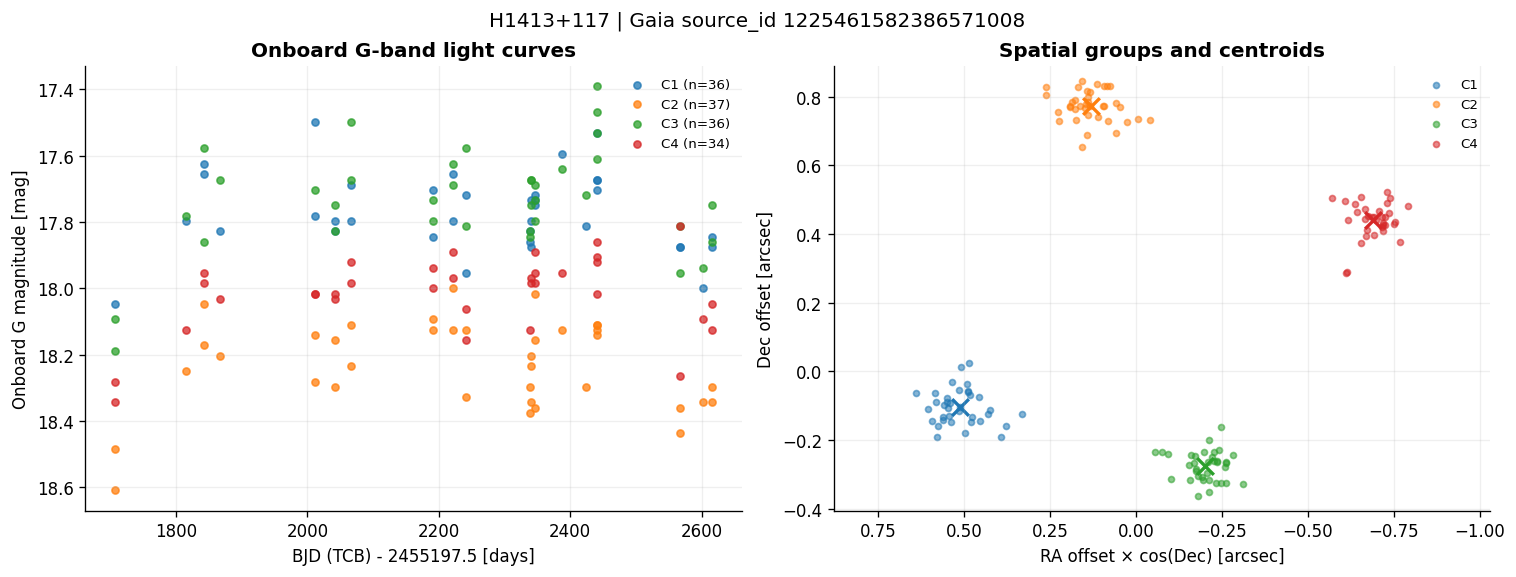

In [10]:
nombre_ejemplo = "H1413+117"
candidatas = validos.loc[validos["lens_name"].eq(nombre_ejemplo)]
if candidatas.empty:
    print("No hay ajustes válidos para", nombre_ejemplo)
else:
    fuente_ejemplo = candidatas.sort_values("observaciones", ascending=False)["source_id"].iloc[0]
    display(candidatas.round(4))
    fig = figura_sistema(nombre_ejemplo, fuente_ejemplo, datos, centros)
    plt.show()

Pares  Delta_G_mediana  Delta_t_max_s
componente_a componente_b                                       
1            2                36          -0.4375         0.0162
             3                35           0.0469         0.0146
             4                33          -0.2344         0.0199
2            3                36           0.5234         0.0195
             4                34           0.1953         0.0171
3            4                33          -0.2812         0.0144

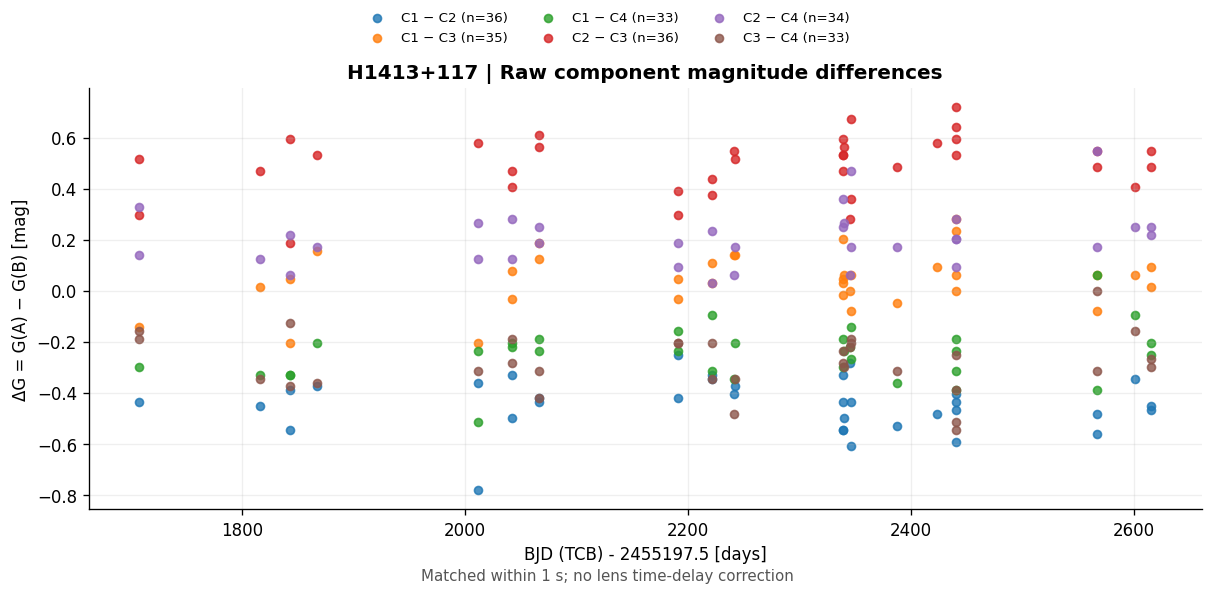

In [11]:
if not candidatas.empty:
    pares_ejemplo = pares.loc[pares["lens_name"].eq(nombre_ejemplo) & pares["source_id"].eq(fuente_ejemplo)]
    if pares_ejemplo.empty:
        print("Este grupo no tiene pares dentro de la tolerancia.")
    else:
        display(pares_ejemplo.groupby(["componente_a", "componente_b"])
                .agg(Pares=("delta_g", "size"), Delta_G_mediana=("delta_g", "median"),
                     Delta_t_max_s=("delta_t_segundos", "max")).round(4))
        fig = figura_diferencias(nombre_ejemplo, fuente_ejemplo, pares, parametros["tolerancia_segundos"])
        plt.show()

## 9. Interpretación y límites

Las figuras permiten revisar qué detecciones forman grupos espaciales y cómo se distribuyen sus magnitudes a bordo en el tiempo. Puede haber pocos pares aun cuando existan numerosas observaciones. Los grupos disponibles también pueden diferir del número de imágenes conocido.

Las diferencias de magnitud son **brutas**. Antes de atribuir variabilidad diferencial a microlensing hace falta comprobar la identificación de imágenes, calibración, incertidumbres, retardos temporales, variabilidad intrínseca y contaminación [5, 6]. Este análisis no estima tamaños de discos de acreción ni masas de microlentes.

También hay que revisar los supuestos de K-means: un $k$ fijado, grupos compactos y sensibilidad a valores atípicos. La estabilidad entre semillas no sustituye la comparación con imágenes de mayor resolución y literatura específica de cada sistema.

## 10. Guardar los resultados

La ejecución completa guarda las observaciones con sus identificadores originales, centros, correspondencias, pares, cobertura y diagnósticos. `results/resumen.json` registra los parámetros.

La última celda guarda las tablas calculadas sin volver a ajustar K-means y comprueba los recuentos. `python run_analysis.py` utiliza las mismas funciones para calcular y exportar el análisis.

In [12]:
resumen, tablas = exportar_resultados(
    raiz, catalogo, originales, datos, excluidas, diagnostico, centros,
    estabilidad, correspondencia, pares, resumen_pares, parametros
)
assert resumen["observaciones_asociadas"] == len(datos)
assert resumen["pares_temporales"] == len(pares)
display(pd.Series({k: v for k, v in resumen.items() if k != "parametros"}, name="Valor").to_frame())
print("Resultados guardados en data/processed/, results/ y figures/.")

Resultados guardados en data/processed/, results/ y figures/.


,Valor
objetivos_catalogo,340
observaciones_originales,34654
filas_exactamente_repetidas,0
observaciones_asociadas,31221
observaciones_excluidas,3433
lentes_con_datos,289
grupos_lente_fuente,379
ajustes_validos,379
ajustes_fallidos,0
componentes_espaciales,864


## Referencias y atribución


1. Gaia Collaboration, Krone-Martins, A. et al. (2024). *Gaia Focused Product Release: A catalogue of sources around quasars to search for strongly lensed quasars*. **A&A, 685, A130**. [DOI](https://doi.org/10.1051/0004-6361/202347273). Datos: ESA et al. (2023), versión 1.0, [DOI 10.57780/esa-sfvnhs3](https://doi.org/10.57780/esa-sfvnhs3).
2. European Space Agency. *Gaia FPR documentation: lens_observation*. [Modelo de datos](https://gea.esac.esa.int/archive/documentation/FPR/chap_datamodel/sec_dm_focused_product_release/ssec_dm_lens_observation.html). Consulta: 1 de octubre de 2026.
3. Arthur, D. & Vassilvitskii, S. (2007). *k-means++: The Advantages of Careful Seeding*. **SODA**, 1027–1035. [Manuscrito de los autores](https://theory.stanford.edu/~sergei/papers/kMeansPP-soda.pdf).
4. Rousseeuw, P. J. (1987). *Silhouettes: A graphical aid to the interpretation and validation of cluster analysis*. **JCAM, 20**, 53–65. [DOI](https://doi.org/10.1016/0377-0427(87)90125-7).
5. Kochanek, C. S. (2004). *Quantitative Interpretation of Quasar Microlensing Light Curves*. **ApJ, 605**, 58–77. [DOI](https://doi.org/10.1086/382180).
6. Paic, E. et al. (2022). *Constraining quasar structure using high-frequency microlensing variations and continuum reverberation*. **A&A, 659, A21**. [DOI](https://doi.org/10.1051/0004-6361/202141808).

Implementación: [documentación oficial de KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html). Las referencias completas están en `references/references.bib`.


Se reconoce la contribución de ESA/Gaia y DPAC. `DATA_SOURCES.md` reúne las condiciones de los datos y la atribución del código base.